/tmp/ipykernel_198418/3364204422.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("tab10", len(probs))


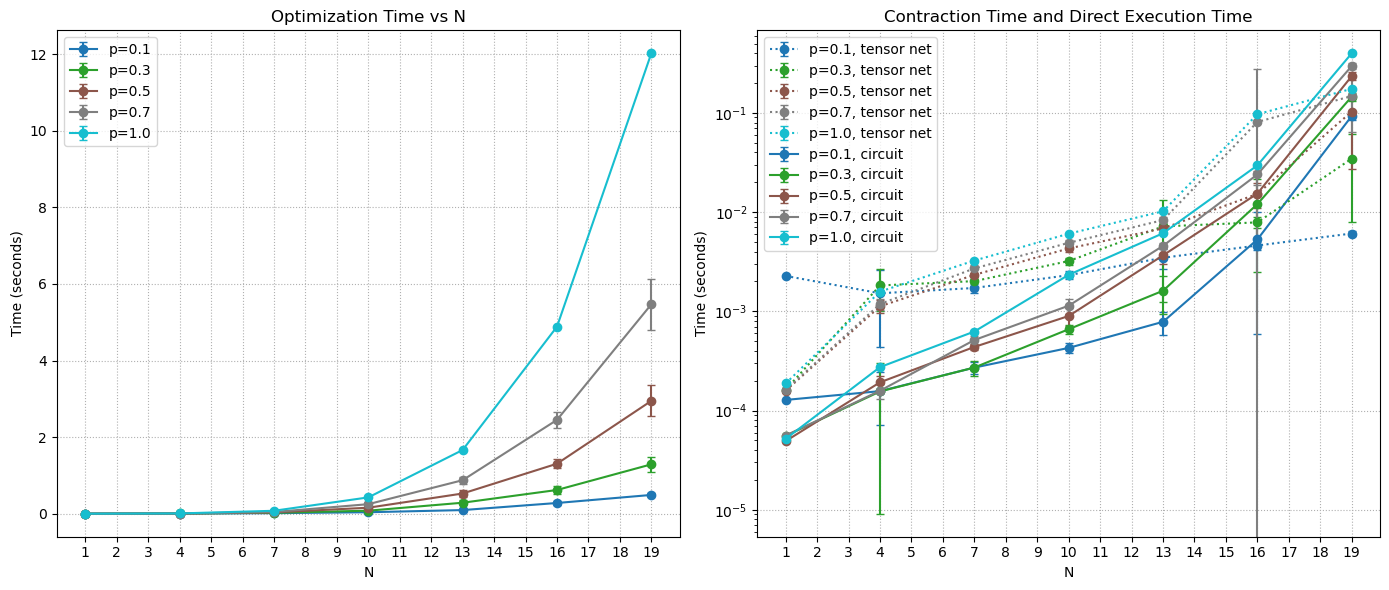

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator

df = pd.read_csv("optimization_and_contraction_times.csv")

probs = sorted(df["probability"].unique())

colors = cm.get_cmap("tab10", len(probs))
color_map = {prob: colors(i) for i, prob in enumerate(probs)}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for prob in probs:
    group = df[df["probability"] == prob]
    color = color_map[prob]

    axes[0].errorbar(group["N"], group["opt_time_mean"], yerr=group["opt_time_std"],
                     label=f"p={prob}", color=color,
                     marker='o', capsize=3)

    ln1 = axes[1].errorbar(group["N"], group["conv_time_mean"], yerr=group["conv_time_std"],
                           label=f"p={prob}, tensor net", color=color, linestyle=':', marker='o',capsize=3)

    ln2 = axes[1].errorbar(group["N"], group["circuit_time_mean"], yerr=group["circuit_time_std"],
                           label=f"p={prob}, circuit", color=color, ls='-', marker='o',capsize=3)

axes[0].set_title("Optimization Time vs N")
axes[0].set_ylabel("Time (seconds)")
axes[0].legend()


handles, labels = axes[1].get_legend_handles_labels()

sorted_items = sorted(zip(labels, handles),
                      key=lambda x: ('circuit' in x[0], x[0]))
labels, handles = zip(*sorted_items)

axes[1].set_yscale("log")
axes[1].set_title("Contraction Time and Direct Execution Time")
axes[1].legend(handles, labels)

for ax in axes:
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, which='both', axis='x')
    ax.set_xlabel("N")
    ax.set_ylabel("Time (seconds)")
    ax.grid(ls=':')

plt.tight_layout()
plt.show()